In [52]:
import requests
import pandas as pd
import numpy as np
import geopandas as gpd
from shapely.geometry import shape
import matplotlib.pyplot as plt
from pathlib import Path
import os
import re
from itertools import product
import time
import json
from typing import Dict, List, Any
from matplotlib.ticker import FuncFormatter

In [2]:
CURRENT_DIRECTORY =  os.getcwd()
SRC_DIRECTORY = Path(CURRENT_DIRECTORY).parents[1]
print(SRC_DIRECTORY)

BASE_DATASET_PATH = Path(SRC_DIRECTORY).parents[0]
BASE_DATASET_PATH = BASE_DATASET_PATH / "datasets"
print(BASE_DATASET_PATH)

/Users/yitong/Desktop/Uni_Skool/Y3 Internship SingHealth/code/Mobile-AED-Study/src
/Users/yitong/Desktop/Uni_Skool/Y3 Internship SingHealth/code/Mobile-AED-Study/datasets


In [3]:
filepath = Path(BASE_DATASET_PATH / "singapore_data/singstat/age_group_per_year.csv")

population_by_age_df = pd.read_csv(filepath)

# strip the header names as they contain trailing whitespace
population_by_age_df.columns = population_by_age_df.columns.str.strip()

years_to_plot = ['2022', '2021', '2020', '2019', '2018', '2017', '2016', '2015', '2014', '2013', '2012', '2011', '2010']
columns_to_keep = ['Data Series'] + years_to_plot
plot_df = population_by_age_df[columns_to_keep].copy()
plot_df

,Data Series,2022,2021,2020,2019,2018,2017,2016,2015,2014,2013,2012,2011,2010
0,Total Residents,4073239,3986842,4044210,4026209,3994283,3965796,3933559,3902690,3870739,3844751,3818205,3789251,3771721
1,0 - 4 Years,178085,178435,183076,185355,185528,187653,187160,183575,181369,183295,186673,188249,194432
2,5 - 9 Years,201360,198760,198737,197775,199066,200575,201509,204452,205790,205704,206324,208119,215675
3,10 - 14 Years,202379,199993,206393,207926,206530,206253,207495,214388,220796,226244,233320,240536,244302
4,15 - 19 Years,206749,204913,215234,222222,226520,232973,239771,242902,247337,255066,258861,260738,263750
5,20 - 24 Years,233303,237720,244537,249079,255516,259072,260854,264127,263918,266889,264506,255069,247190
6,25 - 29 Years,280082,278037,286997,288194,291631,290198,279988,271030,265659,255615,254582,262606,272639
7,30 - 34 Years,317153,301060,297798,293446,281397,279340,285544,290619,292287,296870,295396,297555,298687
8,35 - 39 Years,290981,289221,299515,300818,303720,300956,301998,301067,302029,305503,313970,316161,320024
9,40 - 44 Years,299871,292770,299291,300763,303640,311484,313445,316755,316023,312581,308823,306614,309441


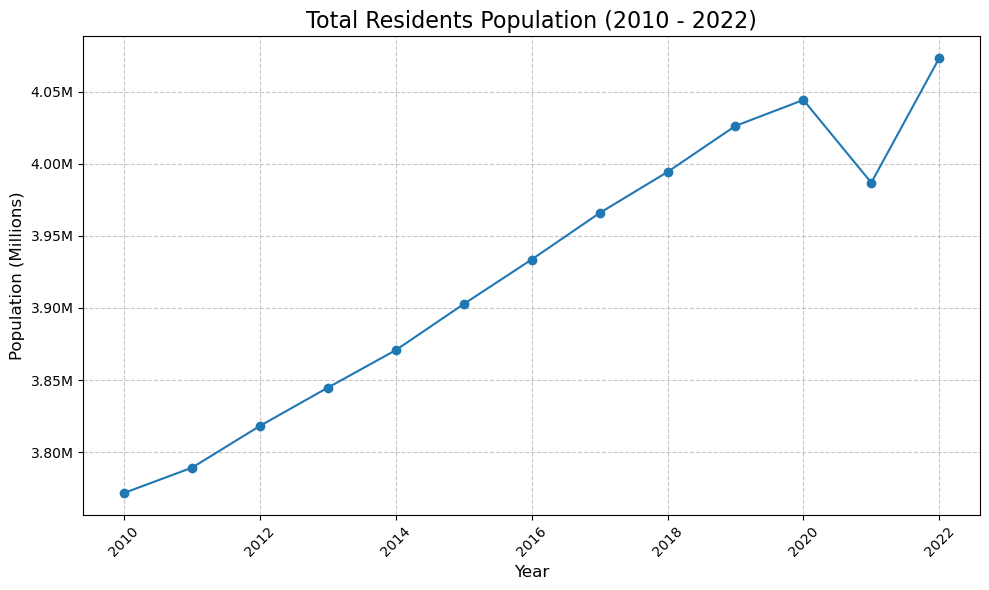

In [4]:
# Total Residents is the first row (index 0)
total_residents_series = plot_df.loc[0, years_to_plot]

# The years are currently columns. For plotting a time series, we want the years on the x-axis.
# We reverse the series so the years are in ascending order (2010 to 2021) for a standard time series plot.
total_residents_plot = total_residents_series.iloc[::-1]

plt.figure(figsize=(10, 6))
total_residents_plot.plot(kind='line', marker='o')

plt.title('Total Residents Population (2010 - 2022)', fontsize=16)
plt.xlabel('Year', fontsize=12)
plt.ylabel('Population (Millions)', fontsize=12)

# Convert y-axis ticks to millions for better readability
def format_millions(x, pos):
    return f'{x / 1000000:.2f}M'

from matplotlib.ticker import FuncFormatter
formatter = FuncFormatter(format_millions)
plt.gca().yaxis.set_major_formatter(formatter)

plt.grid(True, linestyle='--', alpha=0.7)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

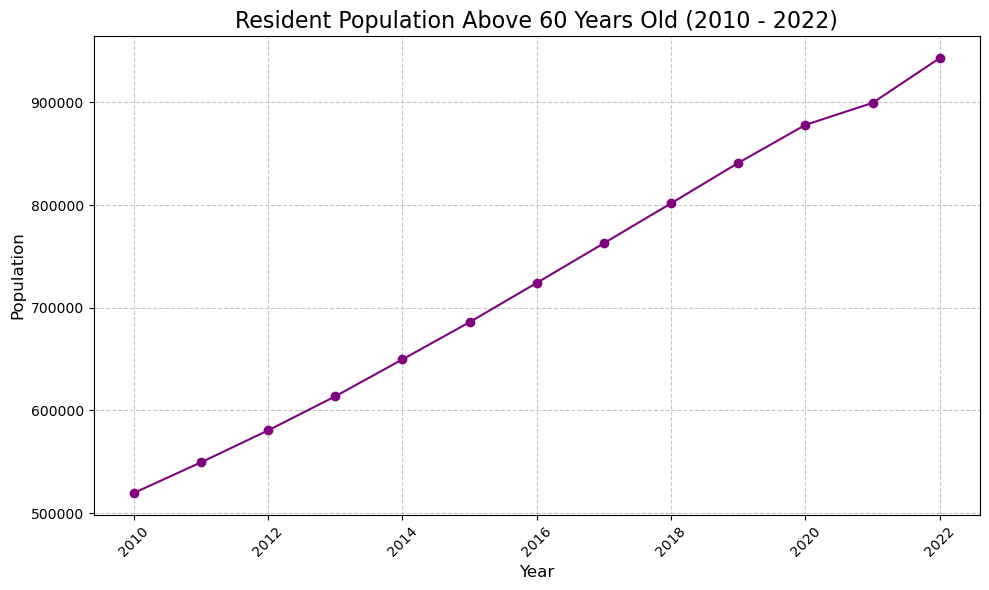

In [5]:
# Select the rows for the population above 60
senior_population_df = plot_df.loc[13:18, years_to_plot]

# Sum the populations across the selected age groups for each year
# .sum(axis=0) calculates the sum down the rows (for each column/year)
senior_population_series = senior_population_df.sum(axis=0)

# Reverse the series for proper time-series order (2010 to 2021)
senior_population_plot = senior_population_series.iloc[::-1]

plt.figure(figsize=(10, 6))
senior_population_plot.plot(kind='line', marker='o', color='purple')

plt.title('Resident Population Above 60 Years Old (2010 - 2022)', fontsize=16)
plt.xlabel('Year', fontsize=12)
plt.ylabel('Population', fontsize=12)
plt.grid(True, linestyle='--', alpha=0.7)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [33]:
age_grp_2010_filepath = Path(BASE_DATASET_PATH / "singapore_data/singstat/2010_age_group_subzone_shorten.xlsx")
age_grp_2020_filepath = Path(BASE_DATASET_PATH / "singapore_data/singstat/2020_age_group_subzone_shorten.xlsx")

age_grp_2010_df = pd.read_excel(age_grp_2010_filepath)
age_grp_2020_df = pd.read_excel(age_grp_2020_filepath)

In [18]:
age_grp_2010_df.head()

,Planning Area of Residence,total,0 - 4,5 - 9,10 - 14,15 - 19,20 - 24,25 - 29,30 - 34,35 - 39,40 - 44,45 - 49,50 - 54,55 - 59,60 - 64,65 & Over
0,Total,3771721,194432,215675,244302,263750,247190,272639,298687,320024,309441,323459,303044,248696,191995,338387
1,Ang Mo Kio,179297,7967,8424,9335,10457,10656,13400,14502,14510,13525,14862,14605,13785,11868,21401
2,Bedok,294519,13230,15018,17489,20083,20156,21265,21707,22751,22018,24615,24632,21891,18018,31646
3,Bishan,91298,3941,4759,5691,7188,6338,5930,6010,7354,7102,8041,8245,6725,5141,8833
4,Bukit Batok,144198,7187,8516,9738,10427,10625,11332,10941,11829,12259,13049,12433,9911,6487,9464


In [19]:
age_grp_2020_df.head()

,Planning Area of Residence,total,0 - 4,5 - 9,10 - 14,15 - 19,20 - 24,25 - 29,30 - 34,35 - 39,...,45 - 49,50 - 54,55 - 59,60 - 64,65 - 69,70 - 74,75 - 79,80 - 84,85 - 89,90 & Over
0,Total,4044210,183080,198740,206390,215230,244540,287000,297800,299520,...,311740,296070,305830,284630,229400,170010,90990,66510,36590,20880
1,Ang Mo Kio,162280,5280,6100,7030,7600,8680,10320,10490,10420,...,12410,11860,12780,12730,11960,9930,5770,4150,2280,1130
2,Bedok,276990,9790,11490,12810,14080,16050,18870,18360,17730,...,21090,20050,21950,21860,19030,15230,8020,5810,3310,1970
3,Bishan,87320,2790,3720,4300,4630,5240,6930,5730,5090,...,6720,6290,6960,7130,5850,4390,2430,1760,1050,560
4,Boon Lay,40,-,-,-,-,-,-,-,-,...,-,-,-,-,-,-,-,-,-,-


<Figure size 1200x700 with 0 Axes>

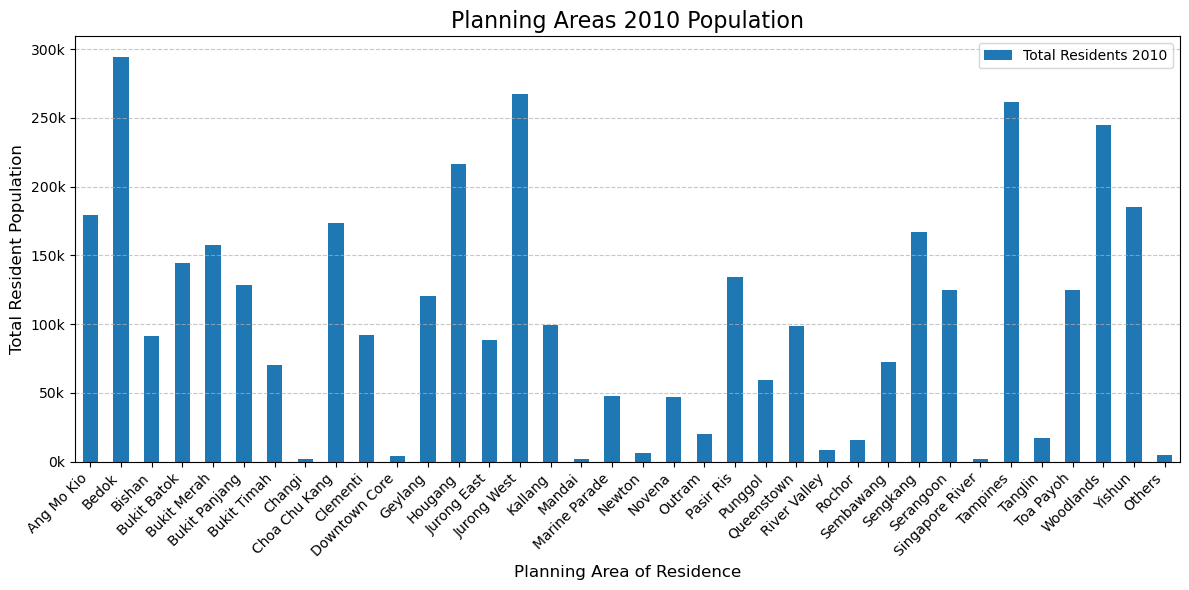

In [45]:
# 1. Select the relevant columns and set 'Planning Area of Residence' as the index
df_2010 = age_grp_2010_df[['Planning Area of Residence', 'total']].copy()


df_2010 = df_2010.set_index('Planning Area of Residence')


# 2. Rename the 'total' columns to indicate the year
df_2010 = df_2010.rename(columns={'total': 'Total Residents 2010'})
# remove the 'total' row
df_2010 = df_2010.drop("Total", axis = 0)

# --- PLOTTING THE BAR CHART ---

plt.figure(figsize=(12, 7))

# Plot the grouped bar chart
df_2010.plot(kind='bar', figsize=(12, 6))

plt.title(f'Planning Areas 2010 Population', fontsize=16)
plt.xlabel('Planning Area of Residence', fontsize=12)
plt.ylabel('Total Resident Population', fontsize=12)

# Convert y-axis ticks to thousands for better readability
def format_thousands(x, pos):
    return f'{int(x / 1000):,}k'

from matplotlib.ticker import FuncFormatter
formatter = FuncFormatter(format_thousands)
plt.gca().yaxis.set_major_formatter(formatter)

plt.xticks(rotation=45, ha='right') # Rotate labels for better fit
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

<Figure size 1200x700 with 0 Axes>

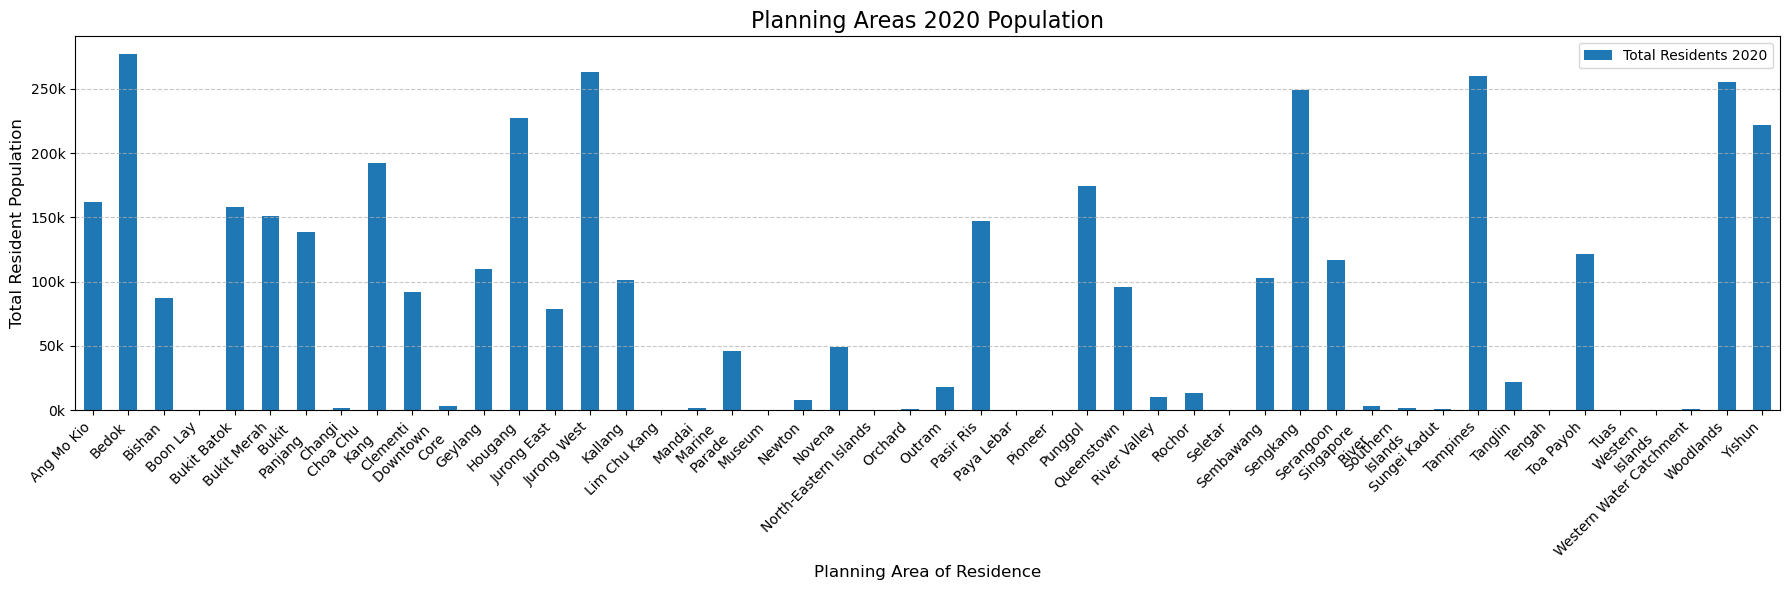

In [44]:
# 1. Select the relevant columns and set 'Planning Area of Residence' as the index
df_2020 = age_grp_2020_df[['Planning Area of Residence', 'total']].copy()

df_2020 = df_2020.set_index('Planning Area of Residence')

# 2. Rename the 'total' columns to indicate the year
df_2020 = df_2020.rename(columns={'total': 'Total Residents 2020'})

# Convert to numeric, forcing errors to NaN
df_2020['Total Residents 2020'] = pd.to_numeric(df_2020['Total Residents 2020'], errors='coerce')

# remove the 'total' row
df_2020 = df_2020.drop("Total", axis = 0)
# drop any rows that resulted in NaN
df_2020 = df_2020.dropna()

plt.figure(figsize=(12, 7))
# Plot the grouped bar chart
df_2020.plot(kind='bar', figsize=(18, 6))

plt.title(f'Planning Areas 2020 Population', fontsize=16)
plt.xlabel('Planning Area of Residence', fontsize=12)
plt.ylabel('Total Resident Population', fontsize=12)
# Convert y-axis ticks to thousands for better readability
def format_thousands(x, pos):
    return f'{int(x / 1000):,}k'

from matplotlib.ticker import FuncFormatter
formatter = FuncFormatter(format_thousands)
plt.gca().yaxis.set_major_formatter(formatter)

plt.xticks(rotation=45, ha='right') # Rotate labels for better fit
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

<Figure size 1200x700 with 0 Axes>

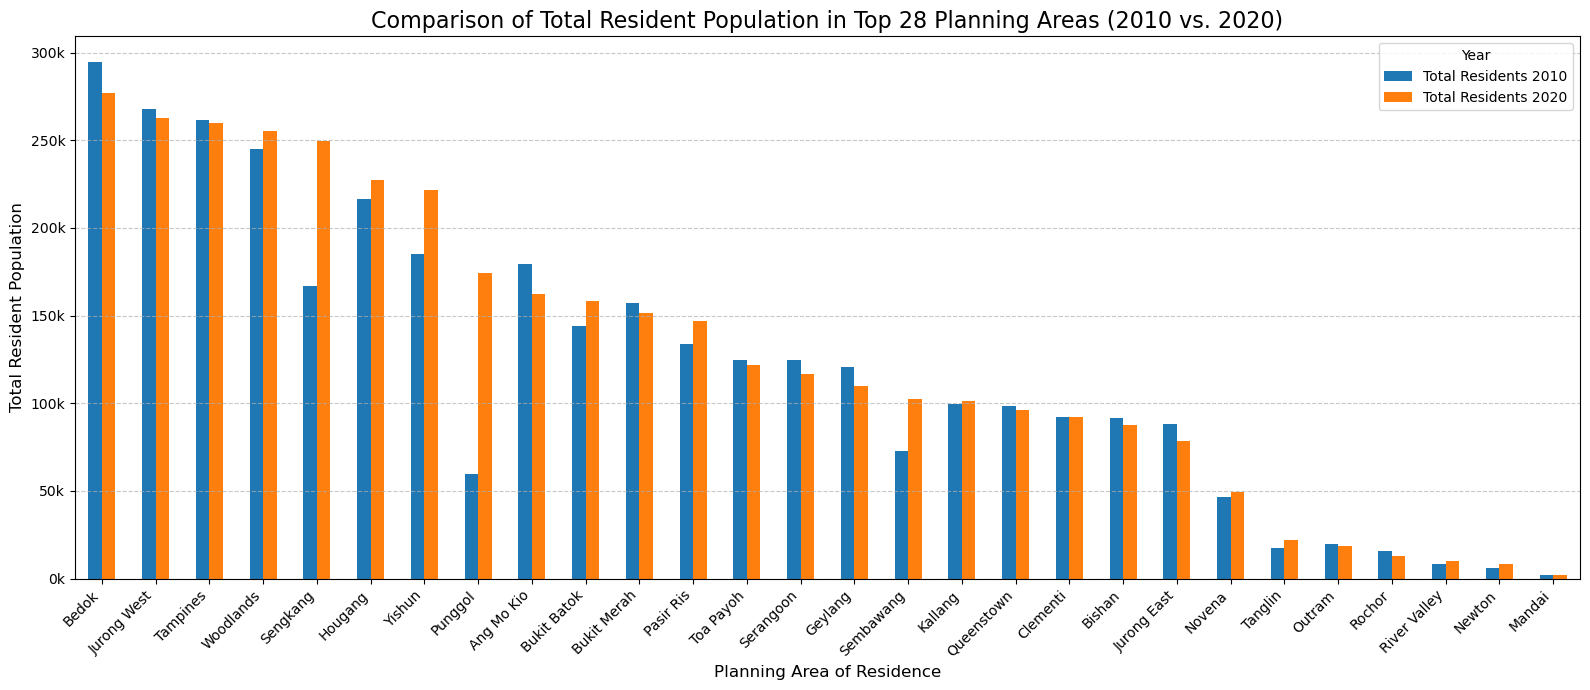

In [51]:
# 1. Select the relevant columns and set 'Planning Area of Residence' as the index
df_2010 = age_grp_2010_df[['Planning Area of Residence', 'total']].copy()
df_2020 = age_grp_2020_df[['Planning Area of Residence', 'total']].copy()

df_2010 = df_2010.set_index('Planning Area of Residence')
df_2020 = df_2020.set_index('Planning Area of Residence')

# 2. Rename the 'total' columns to indicate the year
df_2010 = df_2010.rename(columns={'total': 'Total Residents 2010'})
df_2020 = df_2020.rename(columns={'total': 'Total Residents 2020'})

# 3. Combine the dataframes on the Planning Area index
# We use 'join' to merge the total populations side-by-side.
combined_df = df_2010.join(df_2020)

# 4. Remove the first row which is the overall 'Total' for Singapore
# and also remove the row for 'Boon Lay' which has missing data (NaNs) in the image.
combined_df = combined_df.drop('Total')
combined_df = combined_df.dropna(subset=['Total Residents 2020'])

# 5. Sort the data by the 2020 population and select the top N areas
N = 28
top_areas_df = combined_df.sort_values(by='Total Residents 2020', ascending=False).head(N)


# --- PLOTTING THE BAR CHART ---

plt.figure(figsize=(12, 7))

# Plot the grouped bar chart
top_areas_df.plot(kind='bar', figsize=(16, 7))

plt.title(f'Comparison of Total Resident Population in Top {N} Planning Areas (2010 vs. 2020)', fontsize=16)
plt.xlabel('Planning Area of Residence', fontsize=12)
plt.ylabel('Total Resident Population', fontsize=12)

# Convert y-axis ticks to thousands for better readability
def format_thousands(x, pos):
    return f'{int(x / 1000):,}k'

from matplotlib.ticker import FuncFormatter
formatter = FuncFormatter(format_thousands)
plt.gca().yaxis.set_major_formatter(formatter)

plt.xticks(rotation=45, ha='right') # Rotate labels for better fit
plt.legend(title='Year', fontsize=10)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

In [56]:
age_grp_2010_df.columns

Index(['Planning Area of Residence', 'total', '0 - 4', '5 - 9', '10 - 14',
       '15 - 19', '20 - 24', '25 - 29', '30 - 34', '35 - 39', '40 - 44',
       '45 - 49', '50 - 54', '55 - 59', '60 - 64', '65 & Over'],
      dtype='object')

<Figure size 1200x700 with 0 Axes>

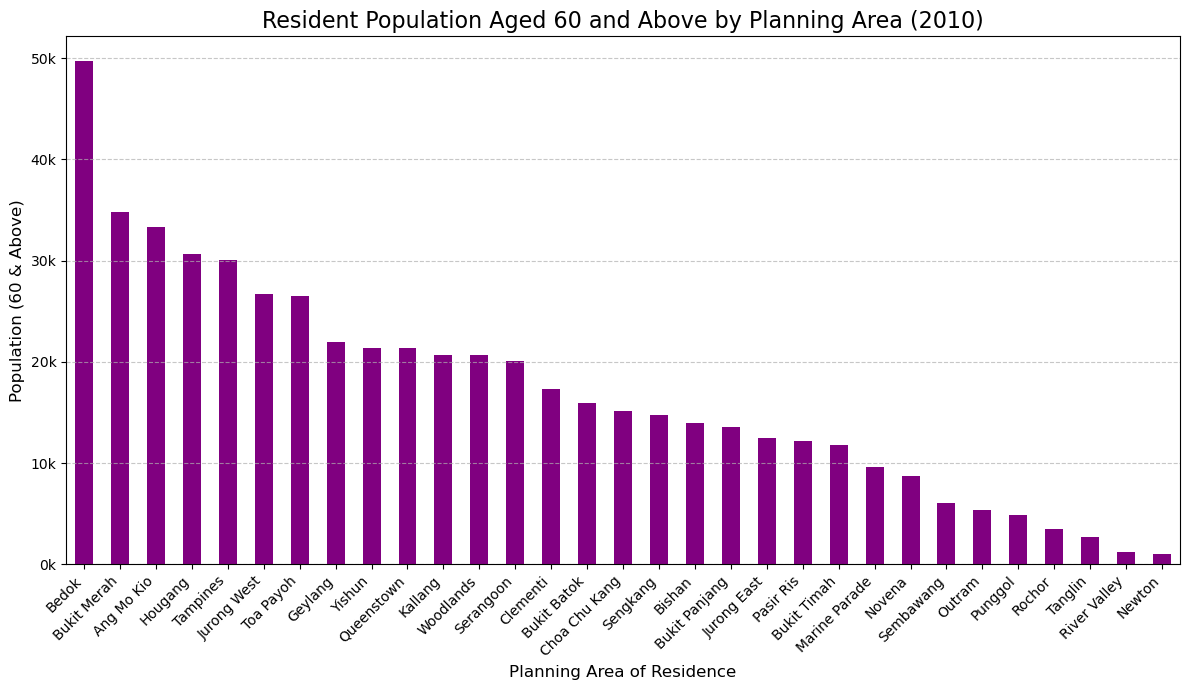

In [ ]:
## Ploting for population aged 60 and above
# 1. Define the columns for population aged 60 and above
age_cols_60_plus = [
    '60 - 64', '65 & Over'
]
cols_to_select = ['Planning Area of Residence'] + age_cols_60_plus

# Select the relevant columns
df_60_plus = age_grp_2010_df[cols_to_select].copy()

# Set 'Planning Area of Residence' as the index
df_60_plus = df_60_plus.set_index('Planning Area of Residence')

# 2. Clean and convert all age columns to numeric
for col in age_cols_60_plus:
    # Convert to numeric, coercing any non-numeric values (like '-') to NaN
    df_60_plus[col] = pd.to_numeric(df_60_plus[col], errors='coerce')

# 3. Sum the columns across the rows (axis=1) to get the total 60+ population per area
df_60_plus['Population 60 & Above'] = df_60_plus[age_cols_60_plus].sum(axis=1)

# 4. Clean up rows: Drop the overall 'Total' row and any rows with missing data (NaN)
df_60_plus = df_60_plus.drop('Total', axis=0, errors='ignore')
df_60_plus = df_60_plus.dropna(subset=['Population 60 & Above'])

# Filter: Drop rows where 'Population 60 & Above' is NaN
df_60_plus = df_60_plus.dropna(subset=['Population 60 & Above'])

# Filter: Keep only rows where population is 1000 or greater
df_60_plus = df_60_plus[df_60_plus['Population 60 & Above'] >= 1000]

# 5. Sort the data for plotting
df_plot = df_60_plus[['Population 60 & Above']].sort_values(
    by='Population 60 & Above',
    ascending=False
)

# --- PLOTTING THE BAR CHART ---
plt.figure(figsize=(12, 7))

df_plot.plot(kind='bar', figsize=(12, 7), legend=False, color='purple')

plt.title('Resident Population Aged 60 and Above by Planning Area (2010)', fontsize=16)
plt.xlabel('Planning Area of Residence', fontsize=12)
plt.ylabel('Population (60 & Above)', fontsize=12)

# Convert y-axis ticks to thousands for better readability
def format_thousands(x, pos):
    if pd.isna(x):
        return ''
    return f'{int(x / 1000):,}k'

formatter = FuncFormatter(format_thousands)
plt.gca().yaxis.set_major_formatter(formatter)

plt.xticks(rotation=45, ha='right')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()

<Figure size 1200x700 with 0 Axes>

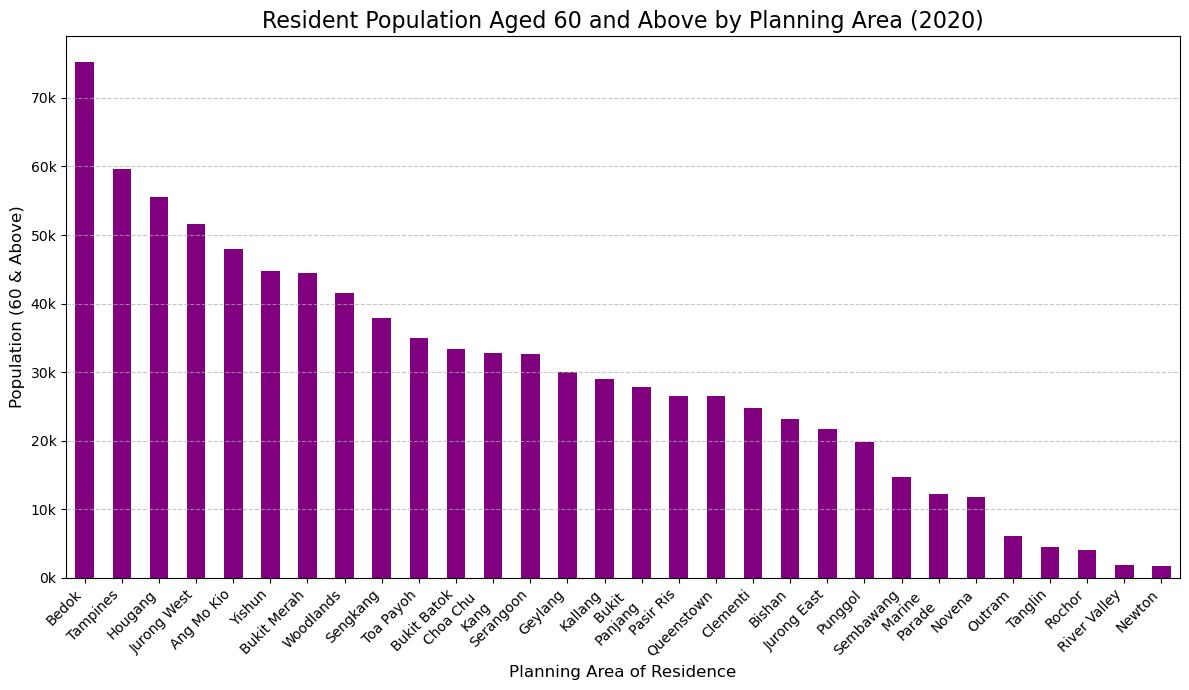

In [ ]:
## Ploting for population aged 60 and above
# 1. Define the columns for population aged 60 and above
age_cols_60_plus = [
    '60 - 64', '65 - 69', '70 - 74', '75 - 79',
    '80 - 84', '85 - 89', '90 & Over'
]
cols_to_select = ['Planning Area of Residence'] + age_cols_60_plus

# Select the relevant columns
df_60_plus = age_grp_2020_df[cols_to_select].copy()

# Set 'Planning Area of Residence' as the index
df_60_plus = df_60_plus.set_index('Planning Area of Residence')

# 2. Clean and convert all age columns to numeric
for col in age_cols_60_plus:
    # Convert to numeric, coercing any non-numeric values (like '-') to NaN
    df_60_plus[col] = pd.to_numeric(df_60_plus[col], errors='coerce')

# 3. Sum the columns across the rows (axis=1) to get the total 60+ population per area
df_60_plus['Population 60 & Above'] = df_60_plus[age_cols_60_plus].sum(axis=1)

# 4. Clean up rows: Drop the overall 'Total' row and any rows with missing data (NaN)
df_60_plus = df_60_plus.drop('Total', axis=0, errors='ignore')
df_60_plus = df_60_plus.dropna(subset=['Population 60 & Above'])

# Filter: Drop rows where 'Population 60 & Above' is NaN
df_60_plus = df_60_plus.dropna(subset=['Population 60 & Above'])

# Filter: Keep only rows where population is 1000 or greater
df_60_plus = df_60_plus[df_60_plus['Population 60 & Above'] >= 1000]

# 5. Sort the data for plotting
df_plot = df_60_plus[['Population 60 & Above']].sort_values(
    by='Population 60 & Above',
    ascending=False
)

# --- PLOTTING THE BAR CHART ---
plt.figure(figsize=(12, 7))

df_plot.plot(kind='bar', figsize=(12, 7), legend=False, color='purple')

plt.title('Resident Population Aged 60 and Above by Planning Area (2020)', fontsize=16)
plt.xlabel('Planning Area of Residence', fontsize=12)
plt.ylabel('Population (60 & Above)', fontsize=12)

# Convert y-axis ticks to thousands for better readability
def format_thousands(x, pos):
    if pd.isna(x):
        return ''
    return f'{int(x / 1000):,}k'

formatter = FuncFormatter(format_thousands)
plt.gca().yaxis.set_major_formatter(formatter)

plt.xticks(rotation=45, ha='right')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()

<Figure size 1500x800 with 0 Axes>

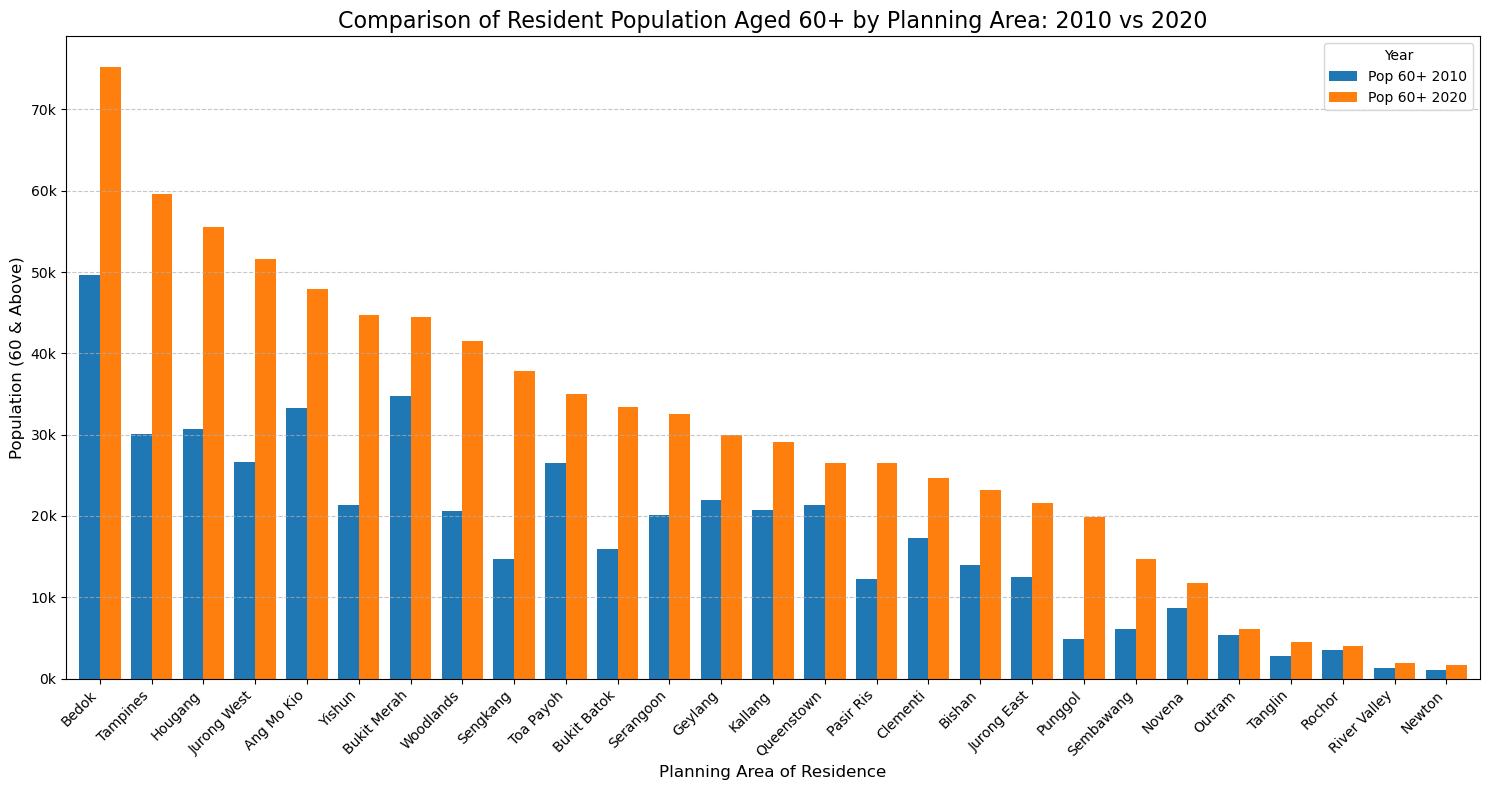

In [ ]:
age_cols_60_plus_2010 = [
    '60 - 64', '65 & Over'
]

age_cols_60_plus_2020 = [
    '60 - 64', '65 - 69', '70 - 74', '75 - 79',
    '80 - 84', '85 - 89', '90 & Over'
]

def calculate_senior_pop(df, year):
    """Calculates the total population aged 60+ for each planning area."""
    
    # Select columns that exist in the DataFrame for the relevant age groups
    if year == 2010:
        existing_cols = [col for col in age_cols_60_plus_2010 if col in df.columns]
    else:
        existing_cols = [col for col in age_cols_60_plus_2020 if col in df.columns]

    cols_to_select = ['Planning Area of Residence'] + existing_cols
    
    df_pop = df[cols_to_select].copy()
    df_pop = df_pop.set_index('Planning Area of Residence')
    
    # Convert all population columns to numeric, coercing errors (e.g., '-' to NaN)
    for col in existing_cols:
        df_pop[col] = pd.to_numeric(df_pop[col], errors='coerce')
        
    # Sum the columns across the rows (axis=1)
    pop_col_name = f'Pop 60+ {year}'
    df_pop[pop_col_name] = df_pop[existing_cols].sum(axis=1)
    
    # Clean up: Drop the overall 'Total' row and any NaNs resulting from coercion
    df_pop = df_pop.drop('Total', axis=0, errors='ignore')
    df_pop = df_pop.dropna(subset=[pop_col_name])
    
    # Filter: Keep only rows where population is 1000 or greater (as per your previous instruction)
    df_pop = df_pop[df_pop[pop_col_name] >= 1000]
    
    return df_pop[[pop_col_name]]

# 2. Process both 2010 and 2020 DataFrames
df_2010_senior = calculate_senior_pop(age_grp_2010_df, 2010)
df_2020_senior = calculate_senior_pop(age_grp_2020_df, 2020)

# 3. Combine the two resulting DataFrames
# Use 'join' to merge them side-by-side based on the Planning Area index
comparison_df = df_2010_senior.join(df_2020_senior, how='inner')

# 4. Sort the result by the 2020 population for better visualization
comparison_df = comparison_df.sort_values(by='Pop 60+ 2020', ascending=False)

# --- PLOTTING THE GROUPED BAR CHART ---

plt.figure(figsize=(15, 8))

# Plot the grouped bar chart
comparison_df.plot(kind='bar', figsize=(15, 8), width=0.8)

plt.title('Comparison of Resident Population Aged 60+ by Planning Area: 2010 vs 2020', fontsize=16)
plt.xlabel('Planning Area of Residence', fontsize=12)
plt.ylabel('Population (60 & Above)', fontsize=12)

# Convert y-axis ticks to thousands for better readability
def format_thousands(x, pos):
    return f'{int(x / 1000):,}k'

from matplotlib.ticker import FuncFormatter
formatter = FuncFormatter(format_thousands)
plt.gca().yaxis.set_major_formatter(formatter)

plt.xticks(rotation=45, ha='right')
plt.legend(title='Year', fontsize=10)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()

In [69]:
workplace_population_filepath = Path(BASE_DATASET_PATH / "singapore_data/singstat/workplace_population_2020_shorten.xlsx")

workplace_population_df_2020 = pd.read_excel(workplace_population_filepath)

workplace_population_df_2020.head()

,planning area,total,Below 25,25 - 29,30 - 34,35 - 39,40 - 44,45 - 49,50 - 54,55 - 59,60 - 64,65 & Over
0,Total,2208358,140505,239835,264464,258988,253633,258046,228496,216057,175383,172950
1,Ang Mo Kio,48180,2032,4779,5377,5001,5100,6579,5476,5184,3931,4720
2,Bedok,59875,3066,5278,5760,6441,6083,6581,6748,7234,6547,6136
3,Bishan,28932,1244,2873,2924,2893,2970,3498,3104,3479,2683,3263
4,Boon Lay,19300,740,1651,2017,2268,2301,2886,2532,2297,1436,1171


<Figure size 1200x700 with 0 Axes>

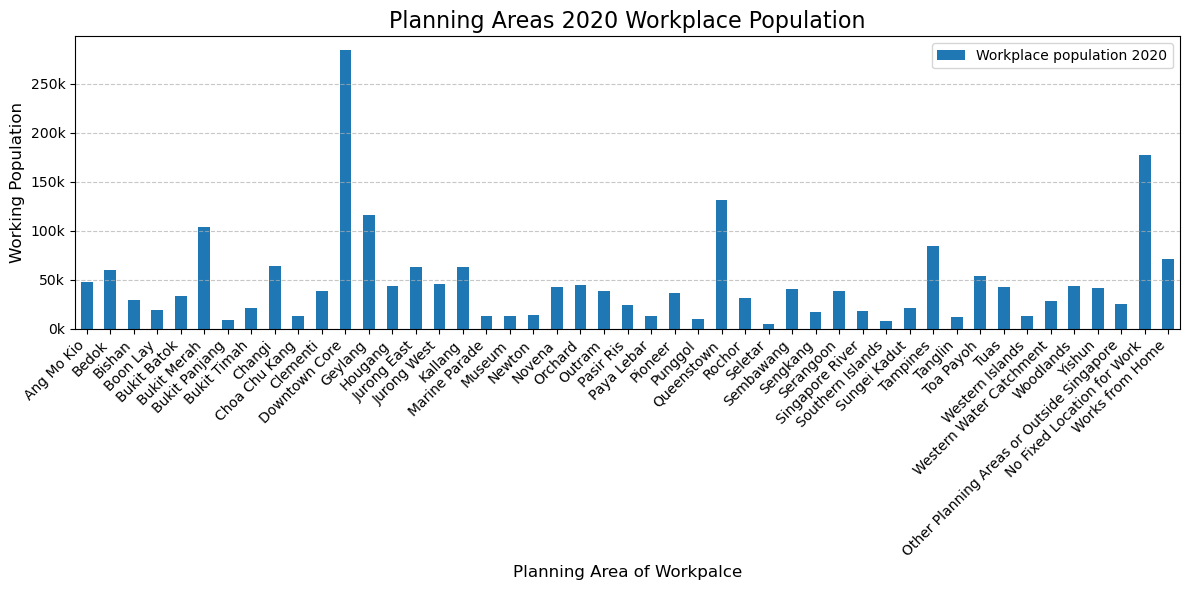

In [70]:
# plotting planning area vs total population
workplace_total_population = workplace_population_df_2020[['planning area', 'total']].copy()


workplace_total_population = workplace_total_population.set_index('planning area')


# 2. Rename the 'total' columns to indicate the year
workplace_total_population = workplace_total_population.rename(columns={'total': 'Workplace population 2020'})
# remove the 'total' row
workplace_total_population = workplace_total_population.drop("Total", axis = 0)

# --- PLOTTING THE BAR CHART ---

plt.figure(figsize=(12, 7))

# Plot the grouped bar chart
workplace_total_population.plot(kind='bar', figsize=(12, 6))

plt.title(f'Planning Areas 2020 Workplace Population', fontsize=16)
plt.xlabel('Planning Area of Workpalce', fontsize=12)
plt.ylabel('Working Population', fontsize=12)

# Convert y-axis ticks to thousands for better readability
def format_thousands(x, pos):
    return f'{int(x / 1000):,}k'

from matplotlib.ticker import FuncFormatter
formatter = FuncFormatter(format_thousands)
plt.gca().yaxis.set_major_formatter(formatter)

plt.xticks(rotation=45, ha='right') # Rotate labels for better fit
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

In [ ]:
workplace_population_df_2020.columns

Index(['planning area', 'total', 'Below 25', '25 - 29', '30 - 34', '35 - 39',
       '40 - 44', '45 - 49', '50 - 54', '55 - 59', '60 - 64', '65 & Over'],
      dtype='object')

<Figure size 1200x700 with 0 Axes>

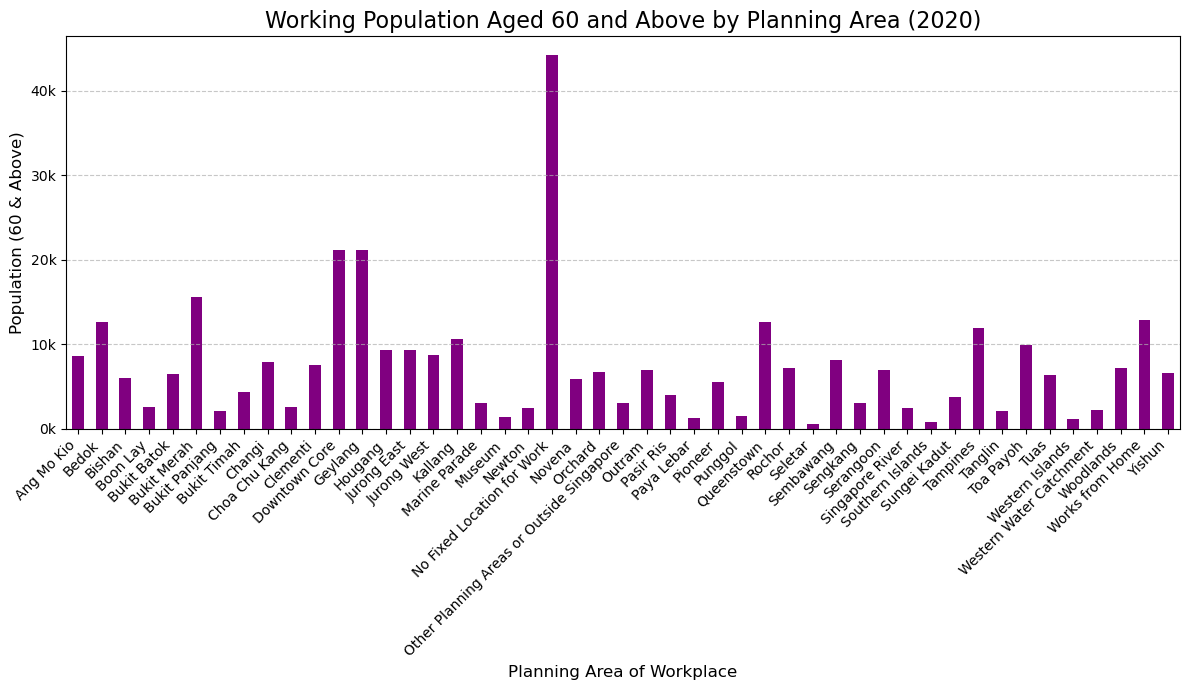

In [81]:
age_cols_60_plus = [
    '60 - 64', '65 & Over'
]
cols_to_select = ['planning area'] + age_cols_60_plus

# Select the relevant columns
df_60_plus = workplace_population_df_2020[cols_to_select].copy()

# Set 'Planning Area of Residence' as the index
df_60_plus = df_60_plus.set_index('planning area')

# 2. Clean and convert all age columns to numeric
for col in age_cols_60_plus:
    # Convert to numeric, coercing any non-numeric values (like '-') to NaN
    df_60_plus[col] = pd.to_numeric(df_60_plus[col], errors='coerce')

# 3. Sum the columns across the rows (axis=1) to get the total 60+ population per area
df_60_plus['Population 60 & Above'] = df_60_plus[age_cols_60_plus].sum(axis=1)

# 4. Clean up rows: Drop the overall 'Total' row and any rows with missing data (NaN)
df_60_plus = df_60_plus.drop('Total', axis=0, errors='ignore')
df_60_plus = df_60_plus.dropna(subset=['Population 60 & Above'])

# Filter: Drop rows where 'Population 60 & Above' is NaN
df_60_plus = df_60_plus.dropna(subset=['Population 60 & Above'])

# 5. Sort the data for plotting
df_plot = df_60_plus[['Population 60 & Above']].sort_values(
    by='planning area'
)

# --- PLOTTING THE BAR CHART ---
plt.figure(figsize=(12, 7))

df_plot.plot(kind='bar', figsize=(12, 7), legend=False, color='purple')

plt.title('Working Population Aged 60 and Above by Planning Area (2020)', fontsize=16)
plt.xlabel('Planning Area of Workplace', fontsize=12)
plt.ylabel('Population (60 & Above)', fontsize=12)

# Convert y-axis ticks to thousands for better readability
def format_thousands(x, pos):
    if pd.isna(x):
        return ''
    return f'{int(x / 1000):,}k'

formatter = FuncFormatter(format_thousands)
plt.gca().yaxis.set_major_formatter(formatter)

plt.xticks(rotation=45, ha='right')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()

In [126]:
highest_edu_2010_filepath = Path(BASE_DATASET_PATH / "singapore_data/singstat/2010_highest_education.xlsx")
highest_edu_2020_filepath = Path(BASE_DATASET_PATH / "singapore_data/singstat/2020_highest_education.xlsx")

highest_edu_2010_df = pd.read_excel(highest_edu_2010_filepath)
highest_edu_2020_df = pd.read_excel(highest_edu_2020_filepath)

In [127]:
highest_edu_2010_df.head()

,planning area,Total,No Qualification,Primary,Lower Secondary,Secondary,Post-Secondary (Non-Tertiary),Polytechnic Diploma,Professional Qualification and Other Diploma,University
0,Total,2779524,424443,193181,282523,526359,307562,250213,161144,634098
1,Ang Mo Kio,140471,28602,11235,15798,24569,13592,11731,7162,27783
2,Bedok,222290,33901,14542,22563,41999,24186,17438,12986,54675
3,Bishan,68301,7486,3189,5256,12913,7417,5384,4621,22035
4,Bukit Batok,106726,14604,6677,9735,19178,11781,10103,6282,28365


In [128]:
highest_edu_2020_df.head()

,planning area,Total,No Qualification,Primary,Lower Secondary,Secondary,Post-Secondary (Non-Tertiary),Polytechnic Diploma,Professional Qualification and Other Diploma,University
0,Total,3140436,333821,173912,258136,505564,341886,301963,217970,1007183
1,Ang Mo Kio,132133,20625,9551,12060,21200,12397,10556,8508,37234
2,Bedok,218749,23987,13335,15887,36058,22719,17306,14389,75068
3,Bishan,69207,5379,2374,4739,9997,5993,5771,4458,30497
4,Bukit Batok,126128,12735,6954,10561,20076,13684,11727,8290,42101


<Figure size 1200x700 with 0 Axes>

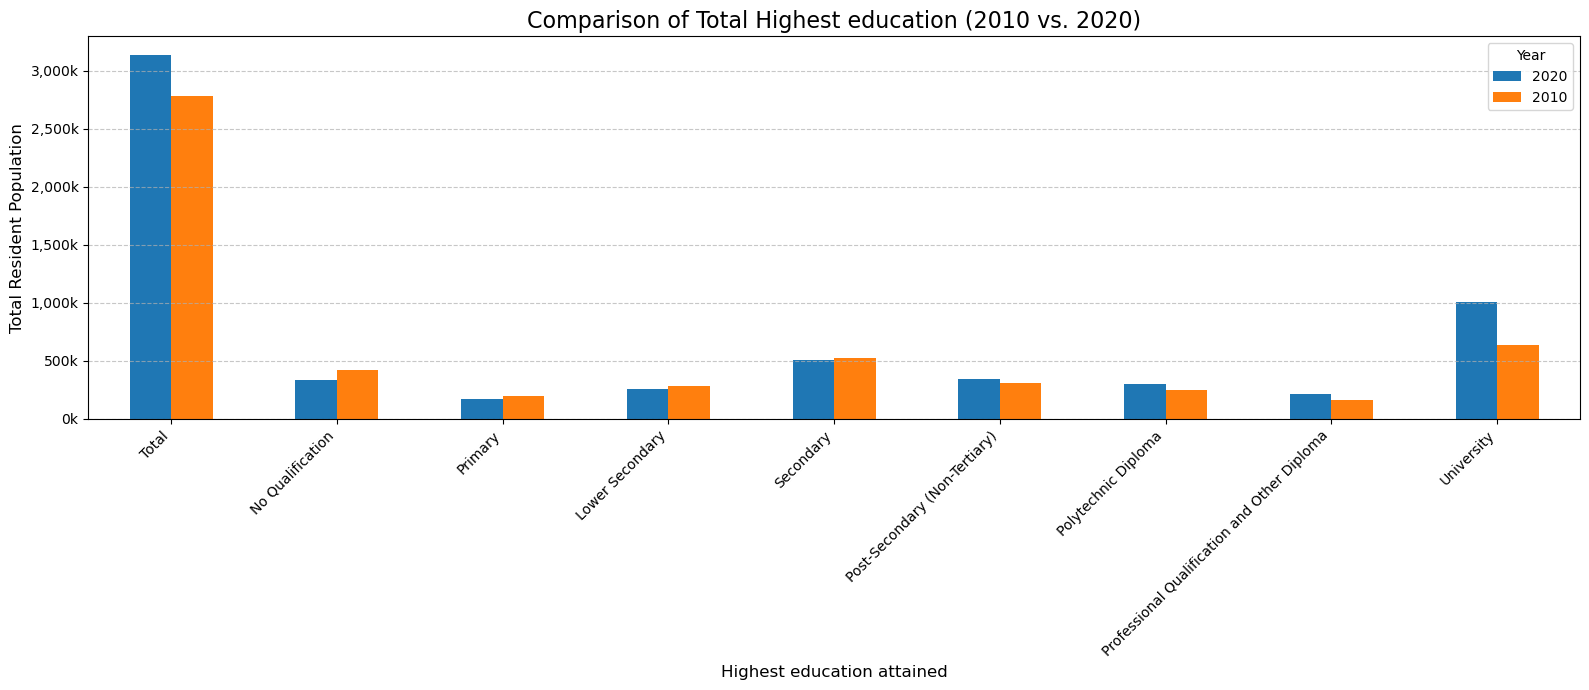

In [143]:
total_2010_series = highest_edu_2010_df[highest_edu_2010_df['planning area'] == 'Total'].copy()

total_2010_series["year"] = 2010
total_2010_value = pd.to_numeric(total_2010_series.iloc[0], errors='coerce')

total_2020_series = highest_edu_2020_df[highest_edu_2020_df['planning area'] == 'Total'].copy()
total_2020_series["year"] = 2020
total_2020_value = pd.to_numeric(total_2020_series.iloc[0], errors='coerce')

# comparison_df = pd.DataFrame(comparison_data).set_index('Year')
comparison_df = pd.concat([total_2020_series, total_2010_series])
comparison_df = comparison_df.set_index('year')
comparison_df = comparison_df.drop("planning area", axis = 1)
# transpose the data for plotting
comparison_df_transposed = comparison_df.T

plt.figure(figsize=(12, 7))

comparison_df_transposed.plot(kind='bar', figsize=(16, 7))
plt.title(f'Comparison of Total Highest education (2010 vs. 2020)', fontsize=16)
plt.xlabel('Highest education attained', fontsize=12)
plt.ylabel('Total Resident Population', fontsize=12)

# Convert y-axis ticks to thousands for better readability
def format_thousands(x, pos):
    return f'{int(x / 1000):,}k'

from matplotlib.ticker import FuncFormatter
formatter = FuncFormatter(format_thousands)
plt.gca().yaxis.set_major_formatter(formatter)

plt.xticks(rotation=45, ha='right') # Rotate labels for better fit
plt.legend(title='Year', fontsize=10)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()
